## Кейс 1
### Бинарная классификация с использованием набора данных об оттоке банковских средств (Предсказание оттока клиентов банка)
### Состав команды: Чмутенко Елена

### Импорты библиотек и константы

In [66]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split, cross_validate, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score, \
    recall_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier, Pool
import optuna
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [67]:
RANDOM_STATE = 42
%matplotlib inline
warnings.filterwarnings("ignore")

### Функции визуализации и вывода метрик

In [68]:
def print_metrics(y_true, y_pred, y_proba,
                  cv_metrics=None,
                  pipeline_name="Logistic Regression",
                  figsize=(8, 8), cmap="Blues"):
    """
    Выводит в консоль метрики по кросс-валидации на трейне. 
    Выводит Classification Report на тесте.
    Строит и показывает матрицу ошибок."""

    if cv_metrics is not None:
        print(f"\nCV-метрики на train ({pipeline_name}):")
        for k, v in cv_metrics.items():
            if k.startswith('test_'):
                metric_name = k.replace('test_', '')
                print(f"  {metric_name:12s}: {v.mean():.2f} ± {v.std():.2f}")

    print("\nClassification Report на test:")
    print(classification_report(y_true, y_pred))
    print(f"PR-AUC (test): {average_precision_score(y_true, y_proba):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap)
    plt.title(f"Confusion matrix {pipeline_name}")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()


def plot_metrics_vs_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    plt.figure(figsize=(10, 8))
    plt.plot(thresholds, precisions[:-1], label='Precision', marker='.', linewidth=2)
    plt.plot(thresholds, recalls[:-1], label='Recall', marker='.', linewidth=2)
    plt.plot(thresholds, f1_scores, label='F1-score', marker='.', linewidth=2, linestyle='--')

    plt.xlabel('Порог классификации', fontsize=11)
    plt.ylabel('Значение метрики', fontsize=11)
    plt.title('Зависимость метрик от порога', fontsize=13, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.7)
    plt.xlim([0.1, 0.9])
    plt.ylim([0.1, 1])
    plt.tight_layout()
    plt.grid(True)
    plt.show()


def plot_catboost_metrics(model, metric_name='Logloss', figsize=(12, 5)):
    """Построение графика обучения для CatBoost модели.
    """
    results = model.get_evals_result()
    if metric_name not in results['learn']:
        raise KeyError(f"Метрика '{metric_name}' отсутствует. Доступные: {list(results['learn'].keys())}")

    epochs = range(len(results['learn'][metric_name]))

    plt.figure(figsize=figsize)
    # Обучающая выборка
    plt.plot(epochs, results['learn'][metric_name],
             label=f'Train ({metric_name})', linewidth=2)
    # Валидационная выборка (если есть)
    if 'validation' in results and metric_name in results['validation']:
        plt.plot(epochs, results['validation'][metric_name],
                 label=f'Validation ({metric_name})', linewidth=2)
        # Вертикальная линия early stopping (если сработал)
    if hasattr(model, 'tree_count_') and model.tree_count_ < len(epochs):
        plt.axvline(x=model.tree_count_, color='red', linestyle='--',
                    label=f'Early Stop (итер. {model.tree_count_})', alpha=0.7)
    plt.xlabel('Итерация', fontsize=11)
    plt.ylabel(metric_name, fontsize=11)
    plt.title(f'Динамика метрики: {metric_name}', fontsize=13, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()


In [69]:
df = pd.read_csv('../../data/preprocessed.csv')
df.sample(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
163016,579,Germany,Female,37,2,113291.05,2,1,0,132467.54,0
95496,579,France,Male,38,3,0.00,2,1,1,132398.54,0
19247,604,Spain,Female,31,1,0.00,2,1,1,62389.12,0
72682,584,Germany,Female,43,7,122227.65,1,1,0,112928.78,1
15784,587,France,Male,31,3,0.00,1,0,0,121866.87,1


### 1. Линейная модель - Логистическая регрессия

#### 1.1 Кодирование категориальных признаков

к колонкам `Gender`, `Geography` с малым количеством категорий применим в пайплайне One-Hot-Encoding

In [70]:
print(df['Gender'].value_counts())
print(df['Geography'].value_counts())

X, y = df.drop(columns='Exited'), df['Exited']
print(X.describe())

num_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Tenure']
ohe_features = ['Gender', 'Geography']
ohe = OneHotEncoder(drop='first', handle_unknown='ignore')

Gender
Male      93150
Female    71884
Name: count, dtype: int64
Geography
France     94215
Spain      36213
Germany    34606
Name: count, dtype: int64
         CreditScore            Age         Tenure        Balance  \
count  165034.000000  165034.000000  165034.000000  165034.000000   
mean      656.454373      38.125883       5.020353   55478.086689   
std        80.103340       8.867207       2.806159   62817.663278   
min       350.000000      18.000000       0.000000       0.000000   
25%       597.000000      32.000000       3.000000       0.000000   
50%       659.000000      37.000000       5.000000       0.000000   
75%       710.000000      42.000000       7.000000  119939.517500   
max       850.000000      92.000000      10.000000  250898.090000   

       NumOfProducts      HasCrCard  IsActiveMember  EstimatedSalary  
count  165034.000000  165034.000000   165034.000000    165034.000000  
mean        1.554455       0.753954        0.497770    112574.822734  
std         0

In [71]:
preprocessor = ColumnTransformer(
    transformers=[
        ('categ', ohe, ohe_features),
        ('num', StandardScaler(), num_cols)
    ], remainder='passthrough'
)

#### 1.2 Пайплайн обучения модели с учетом дисбаланса классов

In [72]:
print(f"Баланс классов: {y.value_counts(normalize=True)}")

skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000,
                               random_state=RANDOM_STATE,
                               class_weight='balanced'  # автоматически взвешивать классы
                               ))
])

Баланс классов: Exited
0    0.788401
1    0.211599
Name: proportion, dtype: float64


#### 1.3 Выбор метрики качества моделей

Accuracy (доля верных ответов) - очень плохой выбор для оценки моделей при дисбалансе классов. 
Рассмотрим другие метрики. Будем учитывать, что в нашей бизнес-задаче важнее не допустить оттока клиентов (class 1 - доля в таргете 21%).

* Precision (точность) - какая доля из помеченных уходящими действительно уйдёт. Второстепенная метрика 
* Recall (полнота) - какую долю модель выявила из реально уходящих. Важная метрика
* F-1 мера - усредненная метрика по точности и полноте. Подходит для несбалансированных данных
* ROC-AUC - интегральная метрика, не требует подбора порога для каждой модели. Хороша для подбора модели, но может ошибаться при дисбалансе классов
* PR-AUC - интегральная метрика, не зависит от порога. Фокусируется на позитивном классе, устойчив к дисбалансу, отражает качество ранжирования

##### Вывод: 
При подборе гиперпараметров в `GridSearch` будем использовать `recall`, но следить и за PR-AUC (scoring=`average_precision`). В classification_report обращаем внимание на 1 класс.


CV-метрики на train (до GridSearch):
  average_precision: 0.58 ± 0.01
  recall      : 0.74 ± 0.00

Classification Report на test:
              precision    recall  f1-score   support

           0       0.91      0.76      0.83     32529
           1       0.45      0.73      0.56      8730

    accuracy                           0.75     41259
   macro avg       0.68      0.75      0.69     41259
weighted avg       0.82      0.75      0.77     41259

PR-AUC (test): 0.5706


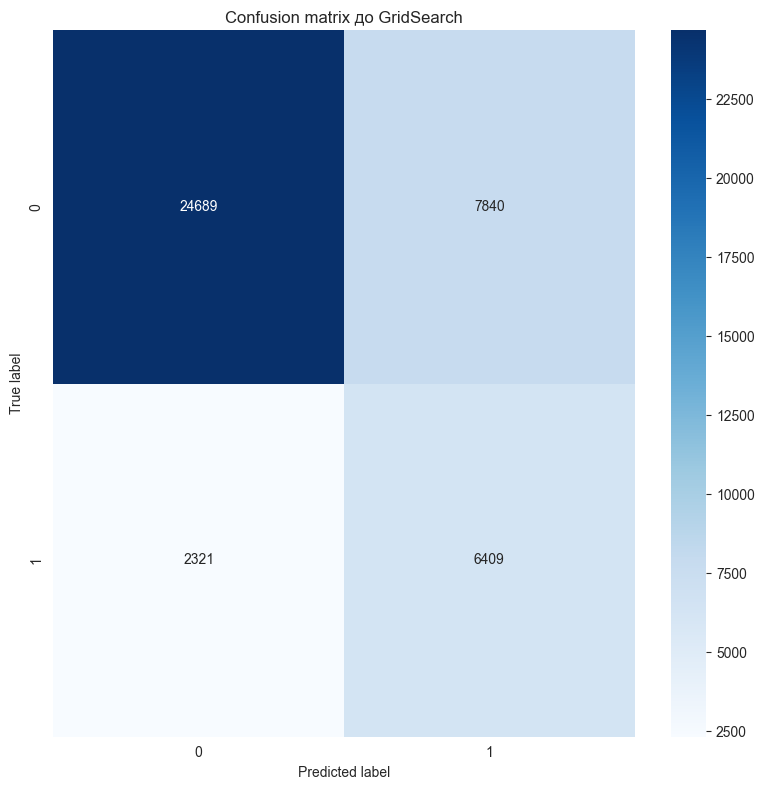

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE, stratify=y)
pipeline_lr.fit(X_train, y_train)

cv_metrics = cross_validate(
    pipeline_lr, X_train, y_train, cv=skf,
    scoring=['average_precision', 'recall'],
    return_train_score=False, n_jobs=-1
)
# Финальная оценка на тесте
y_pred = pipeline_lr.predict(X_test)
y_proba = pipeline_lr.predict_proba(X_test)[:, 1]
print_metrics(y_test, y_pred, y_proba, cv_metrics, "до GridSearch")

Видим на модели LogisticRegression с параметрами по умолчанию и взвешенными классами:
recall 1 класса ~ 0.73 

precision 1 класса ~ 0.45

PR_AUC ~ 0.57

FN 2321 Модель пропускает  (~27%) уходящих клиентов

#### 1.4 Подбор гиперпараметров модели логистической регрессии

In [74]:
param_lr = {
    'clf__C': np.logspace(-3, 1, 10),
    'clf__class_weight': ['balanced', None, {0: 1, 1: 4}]
}

grid = GridSearchCV(pipeline_lr,
                    param_lr,
                    cv=skf,
                    scoring={
                        'pr_auc': 'average_precision',
                        'recall': 'recall'  # Recall (по порогу 0.5)
                    },
                    refit='recall',
                    n_jobs=-1,
                    return_train_score=True,
                    )
start = time.perf_counter()  # perf_counter точнее для замеров длительности
grid.fit(X_train, y_train)
end = time.perf_counter()
total_duration_logreg_base = end - start
print(f"Общее время работы GridSearchCV: {total_duration_logreg_base:.2f} сек")

Общее время работы GridSearchCV: 7.79 сек


In [75]:
best_params = grid.best_params_
print(best_params)
best_model = pipeline_lr.set_params(**best_params)

start_refit = time.perf_counter()
best_model.fit(X_train, y_train)
time_lr = round((time.perf_counter() - start_refit), 2)
print(f"Время обучения модели: {time_lr} сек")

{'clf__C': 0.001, 'clf__class_weight': {0: 1, 1: 4}}
Время обучения модели: 0.16 сек


Видим, что GridSearch подобрал:

С= 0.001 самая сильная регуляризация из набора

class_weight: {0: 1, 1: 4} соответствует исходной перекошенности таргета



#### 1.5 CV-метрики



CV-метрики на train (после GridSearch):
  average_precision: 0.57 ± 0.01
  recall      : 0.75 ± 0.01

Classification Report на test:
              precision    recall  f1-score   support

           0       0.92      0.74      0.82     32529
           1       0.44      0.75      0.55      8730

    accuracy                           0.74     41259
   macro avg       0.68      0.74      0.69     41259
weighted avg       0.82      0.74      0.76     41259

PR-AUC (test): 0.5642


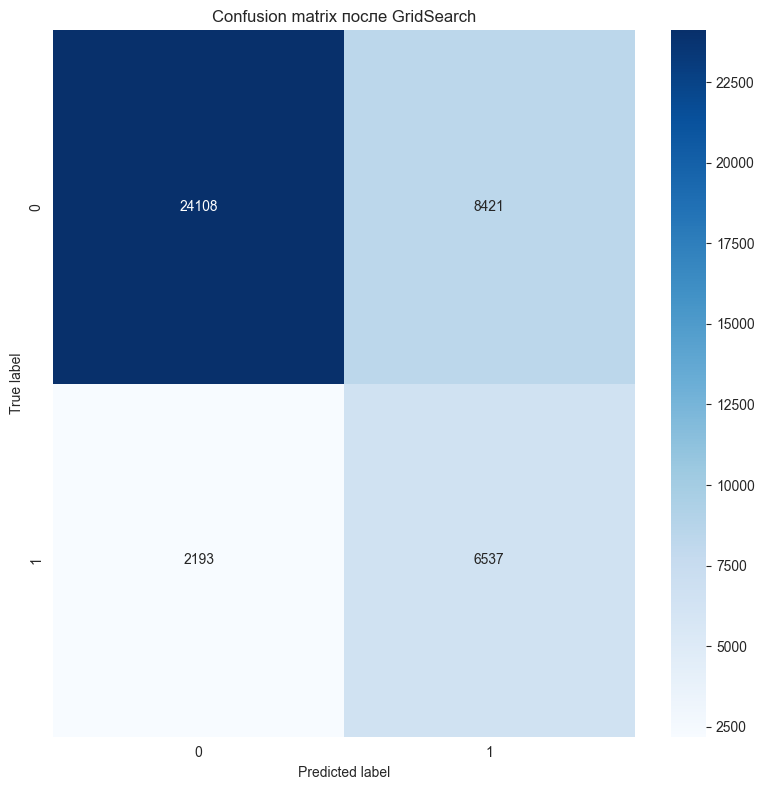

In [76]:
cv_metrics_gs = cross_validate(
    pipeline_lr, X_train, y_train, cv=skf,
    scoring=['average_precision', 'recall'],
    return_train_score=False, n_jobs=-1
)
y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:, 1]
print_metrics(y_test, y_pred_opt, y_proba_opt, cv_metrics_gs, "после GridSearch")

##### Вывод: 

Из модели LogisticRegression c сильной регуляризацией и взвешенными штрафами для несбалансированных классов удалось "выжать" следующие метрики: 

Recall 1 класса ~ 0.75

PR_AUC ~ 0.57

FN=2193 Модель пропускает 25% уходящих клиентов. 


#### 1.5 Подбор порога классификации

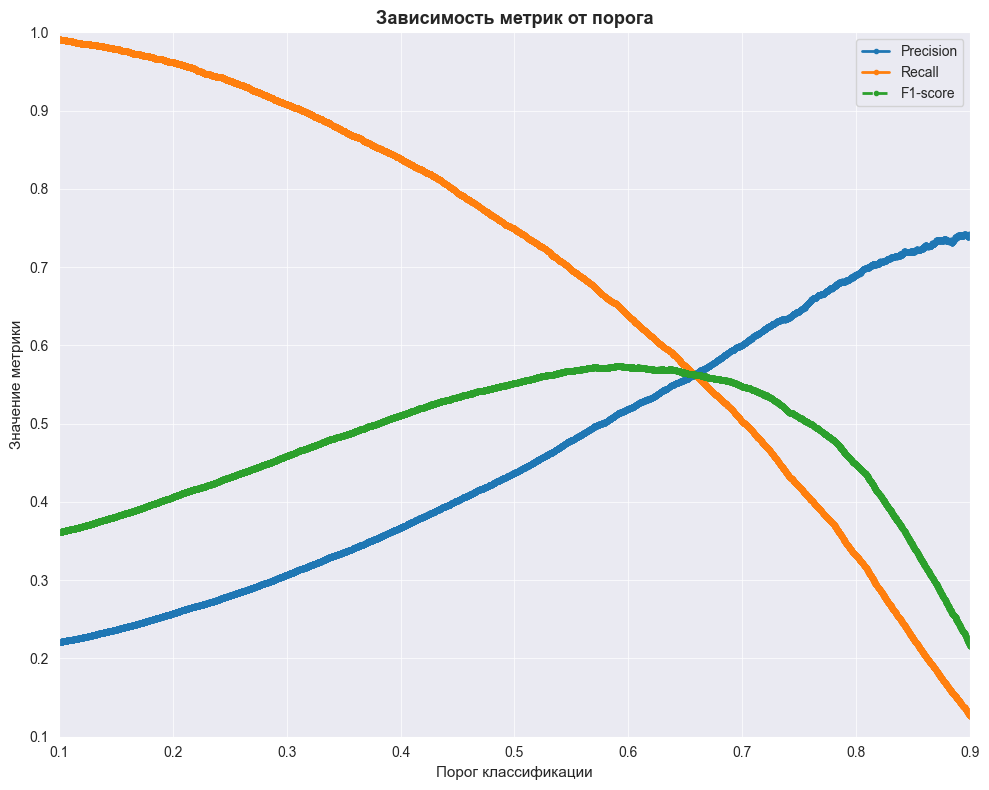

In [77]:
plot_metrics_vs_threshold(y_test, y_proba_opt)

Применим кастомный порог классификации 0.4, чтобы увеличить полноту до ~0.80, точность не ниже 0.35


Classification Report на test:
              precision    recall  f1-score   support

           0       0.93      0.61      0.74     32529
           1       0.37      0.84      0.51      8730

    accuracy                           0.66     41259
   macro avg       0.65      0.73      0.62     41259
weighted avg       0.81      0.66      0.69     41259

PR-AUC (test): 0.5642


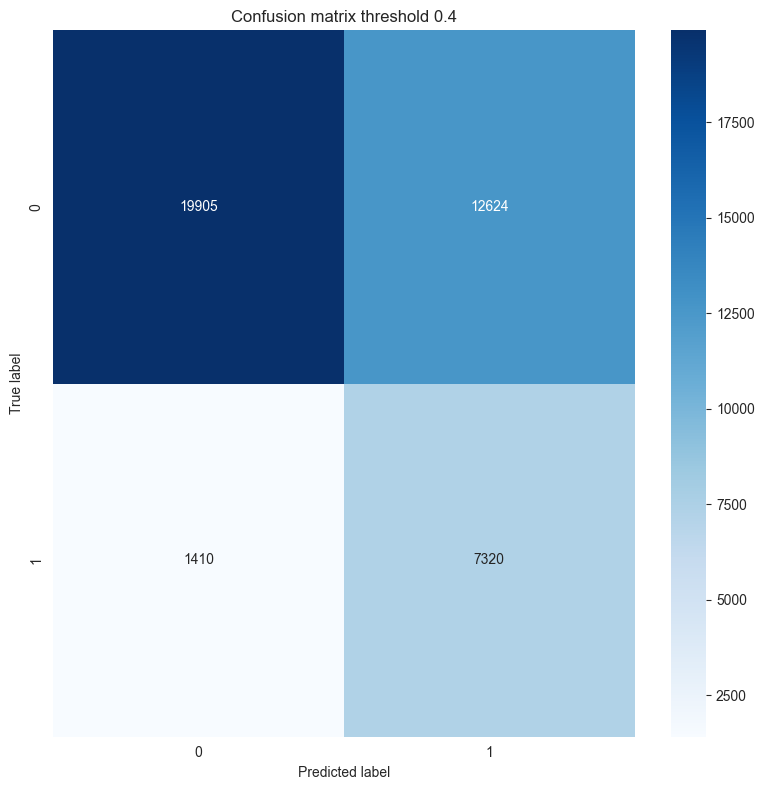

In [78]:
threshold = 0.4
y_pred_custom = (y_proba_opt >= threshold)
print_metrics(y_test, y_pred_custom, y_proba_opt, pipeline_name=f"threshold {threshold}")


Видим, что с кастомным порогом:  

recall 1 класса ~ 0.84   Полнота увеличилась на 8 п.п.

precision 1 класса ~ 0.37 Точность соответственно упала на 7 п.п.

FN 1475 Модель пропускает значительно меньше (~17%) уходящих клиентов. 


#### Baseline : 

Снижение порога классификации эффективно для повышения метрики полноты интересующего нас класса. 
LogisticRegression + GridSearch c сильной регуляризацией, взвешенными штрафами для несбалансированных классов и порогом 0.4 примем за Baseline

recall ~0.83 | PR-AUC ~0.57

#### 1.6 Feature Engineering

#### PolynomialFeatures

Новые лучшие параметры: {'clf__C': 0.1, 'clf__class_weight': {0: 1, 1: 4}, 'clf__l1_ratio': 0.0}

Classification Report на test:
              precision    recall  f1-score   support

           0       0.93      0.62      0.75     32529
           1       0.37      0.83      0.51      8730

    accuracy                           0.67     41259
   macro avg       0.65      0.73      0.63     41259
weighted avg       0.81      0.67      0.70     41259

PR-AUC (test): 0.5691


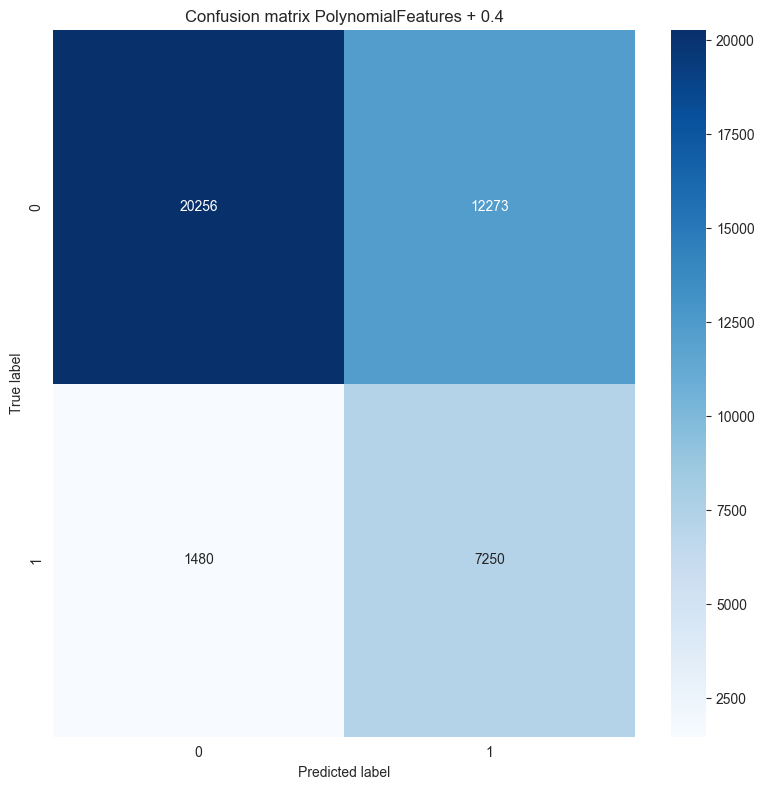

In [79]:
preprocessor = ColumnTransformer([
    ('poly', Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False))
    ]), num_cols),
    ('categ', ohe, ohe_features),
], remainder='passthrough')

param_grid_pf = {
    'clf__C': [0.1, 0.5, 1.0, 5.0],  # принудительно убираем 0.01  
    'clf__l1_ratio': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0],  # добавили чистый Ridge (0.0)
    'clf__class_weight': ['balanced', {0: 1, 1: 4}]
}

pf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        penalty='elasticnet',  # ← ОБЯЗАТЕЛЬНО для работы l1_ratio
        solver='saga',
        max_iter=5000,
        random_state=RANDOM_STATE))
])
grid_pf = GridSearchCV(
    pf_pipeline,
    param_grid=param_grid_pf,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    refit=True
)
grid_pf.fit(X_train, y_train)
print("Новые лучшие параметры:", grid_pf.best_params_)

y_proba_poly = grid_pf.predict_proba(X_test)[:, 1]
y_pred_poly = (y_proba_poly >= threshold)

print_metrics(y_test, y_pred_poly, y_proba_poly, pipeline_name=f"PolynomialFeatures + {threshold}")

#### Выводы: 
После добавления PolynomialFeatures метрики всё ещё не растут


#### Сэмплирование - SMOTE (Synthetic Minority Oversampling Techniques)

In [80]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline
from collections import Counter

preprocessor = ColumnTransformer(
    transformers=[
        ('categ', ohe, ohe_features),
        ('num', StandardScaler(), num_cols)
    ], remainder='passthrough'
)

pipeline_smote = make_pipeline(
    preprocessor,
    SMOTE(random_state=RANDOM_STATE, k_neighbors=5),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)
pipeline_smote.fit(X_train, y_train)

print("Баланс классов до семплирования:", Counter(y_train))

X_train_num = preprocessor.transform(X_train)
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X_train_num, y_train)

print("Баланс классов после SMOTE:", Counter(y_resampled))

Баланс классов до семплирования: Counter({0: 97584, 1: 26191})
Баланс классов после SMOTE: Counter({1: 97584, 0: 97584})


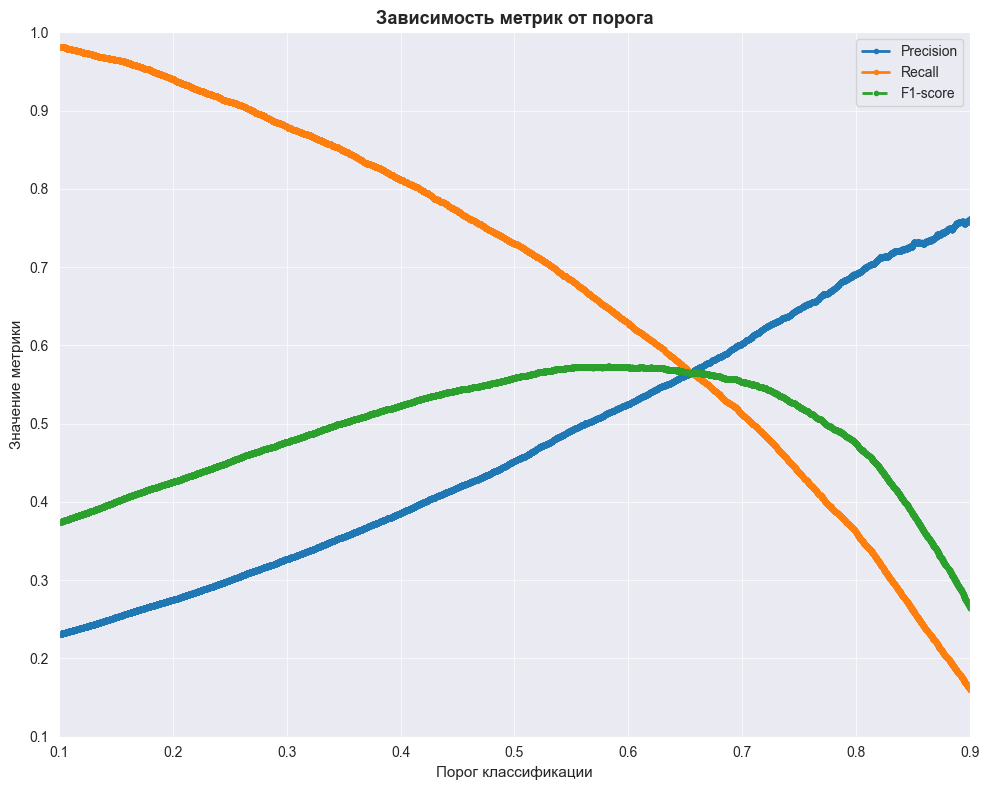


Classification Report на test:
              precision    recall  f1-score   support

           0       0.93      0.65      0.77     32529
           1       0.39      0.81      0.52      8730

    accuracy                           0.69     41259
   macro avg       0.66      0.73      0.64     41259
weighted avg       0.81      0.69      0.72     41259

PR-AUC (test): 0.5733


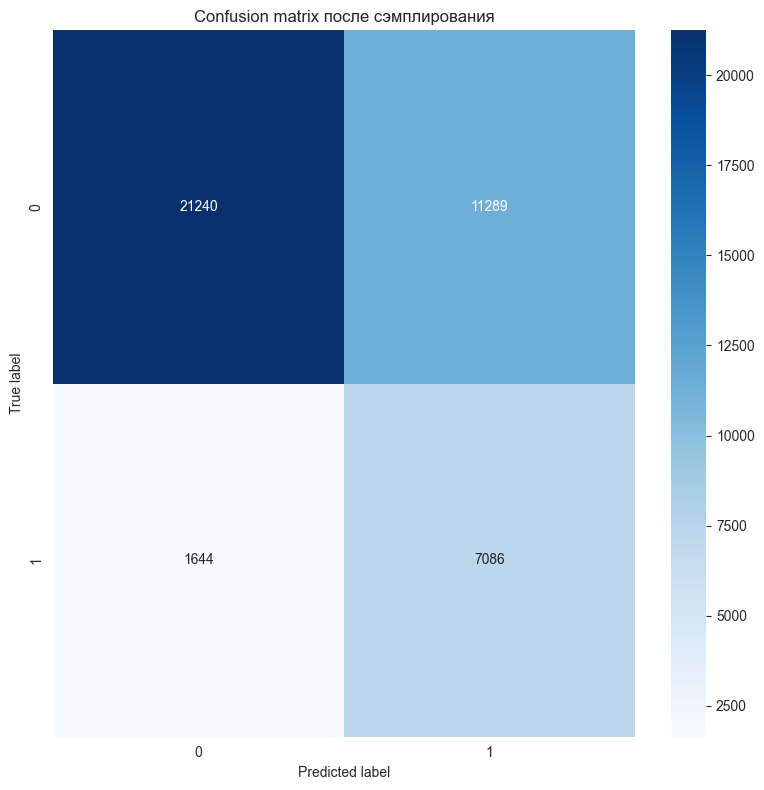

In [81]:
y_proba_sm = pipeline_smote.predict_proba(X_test)[:, 1]
plot_metrics_vs_threshold(y_test, y_proba_sm)
y_pred_sm = (y_proba_sm >= threshold)
print_metrics(y_test, y_pred_sm, y_proba_sm, pipeline_name="после сэмплирования")

Результаты хуже, чем у Baseline с тем же порогом

#### Выводы: 
Простые способы Feature Engineering не принесли свои плоды. Переходим к нелинейным моделям

### 2. Решающее дерево

#### 2.1 Базовая модель + GridSearchCV

In [82]:
dtc = DecisionTreeClassifier(random_state=RANDOM_STATE)
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

tree_preproc = ColumnTransformer(transformers=[
    ('categ', ohe, ohe_features)
], remainder='passthrough',
    verbose_feature_names_out=False
)
pipeline = Pipeline([
    ('preprocessor', tree_preproc),
    ('clf', dtc)])
param_grid = {
    'clf__max_depth': range(2, 8),
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': range(1, 5),
    'clf__max_features': ['sqrt', 'log2'],
    'clf__class_weight': ['balanced', {0: 1, 1: 4}],
}
gs = GridSearchCV(pipeline,
                  param_grid=param_grid,
                  cv=skf,
                  scoring='recall',
                  n_jobs=-1,
                  refit=True)
start = time.perf_counter()  # perf_counter точнее для замеров длительности
gs.fit(X_train, y_train)
end = time.perf_counter()
total_duration_gs = end - start
print(f"Общее время работы GridSearchCV: {total_duration_gs:.2f} сек")

print(f'Лучшие параметры: {gs.best_params_}')
print(f'Лучшее качество на кросс-валидации: {gs.best_score_:.4f}')

Общее время работы GridSearchCV: 18.49 сек
Лучшие параметры: {'clf__class_weight': 'balanced', 'clf__max_depth': 3, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
Лучшее качество на кросс-валидации: 0.9172


#### 2.2 CV-метрики


CV-метрики на train (DecisionTree + GridSearch + порог 0.4):
  precision   : 0.28 ± 0.00
  recall      : 0.92 ± 0.00
  average_precision: 0.35 ± 0.00

Classification Report на test:
              precision    recall  f1-score   support

           0       0.96      0.34      0.50     32529
           1       0.28      0.95      0.43      8730

    accuracy                           0.47     41259
   macro avg       0.62      0.64      0.46     41259
weighted avg       0.82      0.47      0.48     41259

PR-AUC (test): 0.3573


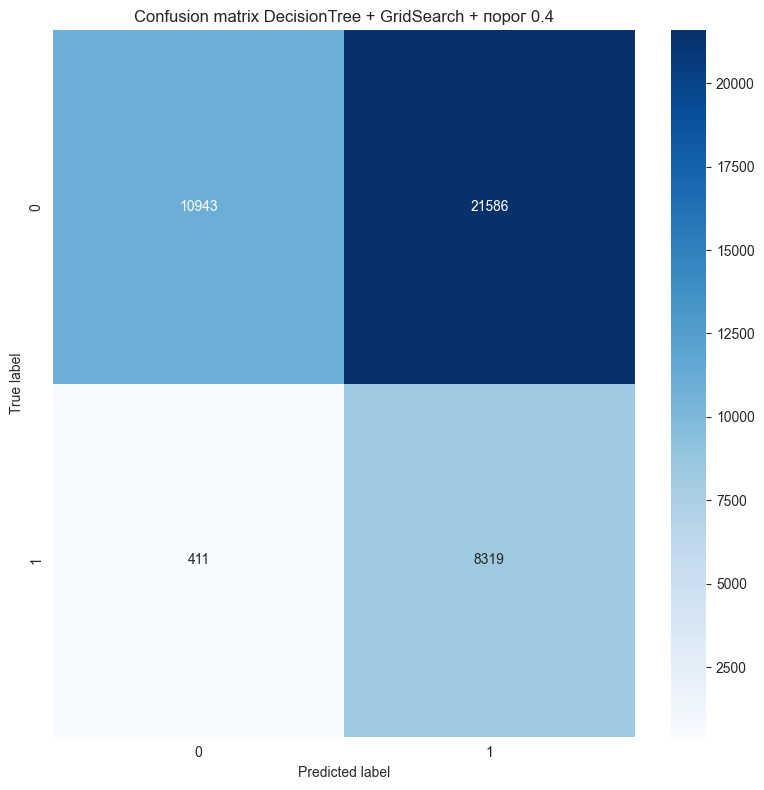

In [83]:
cv_metrics_dt_gs = cross_validate(
    gs.best_estimator_, X_train, y_train, cv=skf,
    scoring=['precision', 'recall', 'average_precision'],
    return_train_score=False, n_jobs=-1
)

y_proba_dt_gs = gs.predict_proba(X_test)[:, 1]
y_pred_dt_gs = (y_proba_dt_gs >= threshold)
print_metrics(y_test, y_pred_dt_gs, y_proba_dt_gs, cv_metrics_dt_gs, "DecisionTree + GridSearch + порог 0.4")

Видим метрики на тестовой выборке

recall 1 класса 0.91 выше на 16 п.п., чем у Baseline 

PR-AUC ~0.36 существенно ниже

FN=778 Модель пропускает ~9% уходящих клиентов

#### 2.2 Улучшение. Подбор параметров и порога

In [84]:
def objective(trial):
    max_depth = trial.suggest_int('max_depth', 2, 10)
    min_samples_split = trial.suggest_int('min_samples_split', 3, 15)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 8)
    max_features = trial.suggest_categorical('max_features', [None, 'sqrt', 'log2'])
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])

    model = DecisionTreeClassifier(random_state=RANDOM_STATE,
                                   max_depth=max_depth,
                                   min_samples_split=min_samples_split,
                                   min_samples_leaf=min_samples_leaf,
                                   max_features=max_features,
                                   class_weight=class_weight)
    pipeline = Pipeline([
        ('preprocessor', tree_preproc),
        ('clf', model)
    ])
    recall = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring="recall", n_jobs=1).mean()
    return recall

In [85]:
study = optuna.create_study(direction='maximize', study_name="DecisionTree")

start = time.perf_counter()
study.optimize(objective, n_trials=40, timeout=50, show_progress_bar=True)
total_duration_dt_op = time.perf_counter() - start

[I 2026-04-27 14:37:54,810] A new study created in memory with name: DecisionTree


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-04-27 14:37:55,777] Trial 0 finished with value: 0.5418273024460414 and parameters: {'max_depth': 10, 'min_samples_split': 14, 'min_samples_leaf': 7, 'max_features': None, 'class_weight': None}. Best is trial 0 with value: 0.5418273024460414.
[I 2026-04-27 14:37:56,130] Trial 1 finished with value: 0.6980279757132277 and parameters: {'max_depth': 6, 'min_samples_split': 14, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.6980279757132277.
[I 2026-04-27 14:37:56,498] Trial 2 finished with value: 0.6049408002228891 and parameters: {'max_depth': 2, 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.6980279757132277.
[I 2026-04-27 14:37:56,795] Trial 3 finished with value: 0.1657852974483923 and parameters: {'max_depth': 4, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 1 with value: 0.6

In [86]:
print(f"\nОбщее время работы Optuna: {total_duration_dt_op:.2f} сек")
print(f'Лучшие параметры: {study.best_params}')
print(f"CV-метрика Recall на train (среднее): {study.best_value:.4f}")


Общее время работы Optuna: 14.22 сек
Лучшие параметры: {'max_depth': 3, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': 'balanced'}
CV-метрика Recall на train (среднее): 0.9172


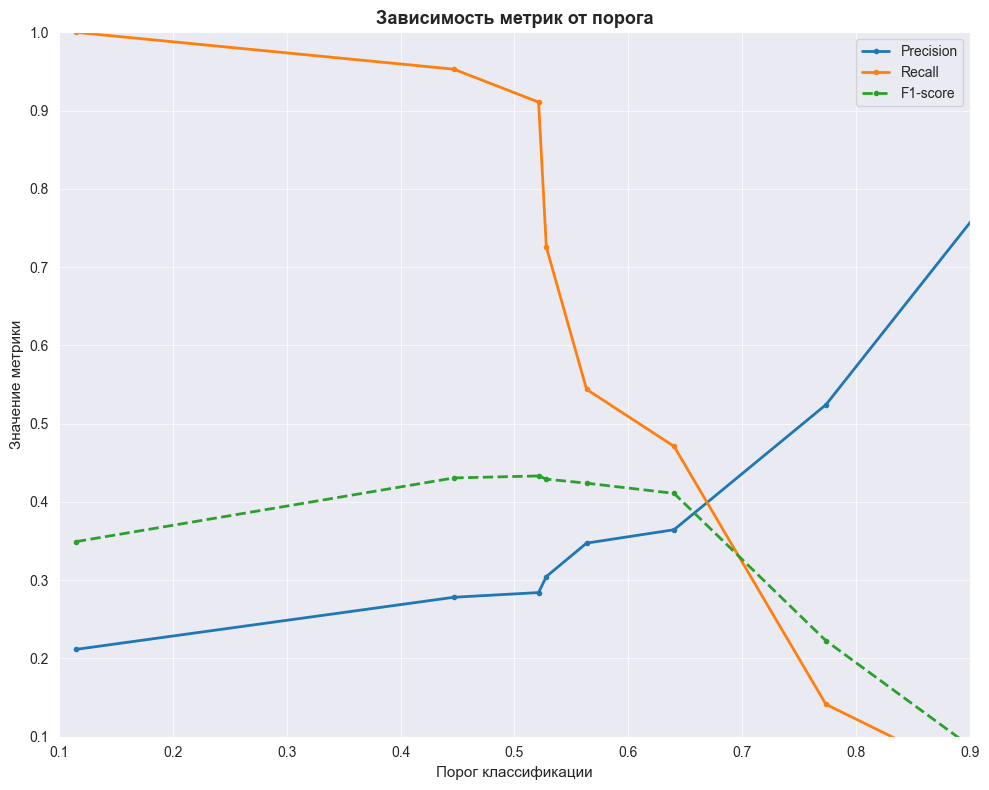


CV-метрики на train (DecisionTree + Optuna + порог 0.45):
  average_precision: 0.35 ± 0.00
  recall      : 0.92 ± 0.00

Classification Report на test:
              precision    recall  f1-score   support

           0       0.96      0.34      0.50     32529
           1       0.28      0.95      0.43      8730

    accuracy                           0.47     41259
   macro avg       0.62      0.64      0.46     41259
weighted avg       0.82      0.47      0.48     41259

PR-AUC (test): 0.3573


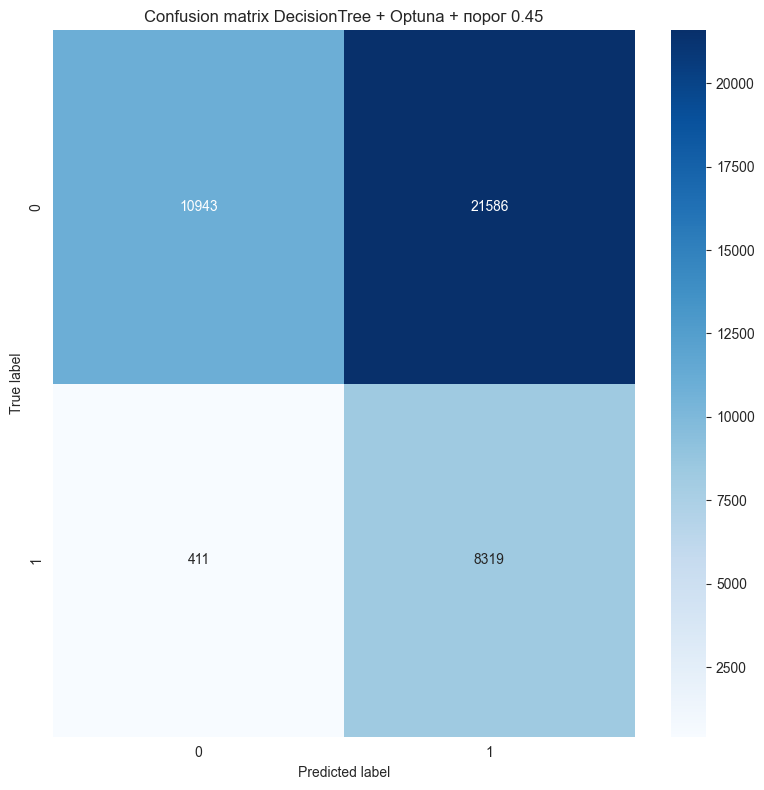

In [87]:
pipeline_dt = Pipeline([
    ('preprocessor', tree_preproc),
    ('clf', DecisionTreeClassifier(**study.best_params, random_state=RANDOM_STATE))
])
start_dt = time.perf_counter()
pipeline_dt.fit(X_train, y_train)
time_dt = round(time.perf_counter() - start_dt, 2)

proba_op = pipeline_dt.predict_proba(X_test)[:, 1]

threshold_dt = 0.45
plot_metrics_vs_threshold(y_test, proba_op)
pred_op = (proba_op >= threshold)
cv_metrics_dt_opt = cross_validate(
    pipeline_dt, X_train, y_train, cv=skf,
    scoring=['average_precision', 'recall'],
    return_train_score=False, n_jobs=-1
)
print_metrics(y_test, pred_op, proba_op, cv_metrics_dt_opt, "DecisionTree + Optuna + порог 0.45")

#### Вывод:
 
у Optuna большой выигрыш по времени и диапазону параметров

Решающее дерево с учетом того же порога 0.4 показало лучший Recall=0.95

Посмотрим на наше прекрасное дерево)

#### 2.3 Визуализация дерева 

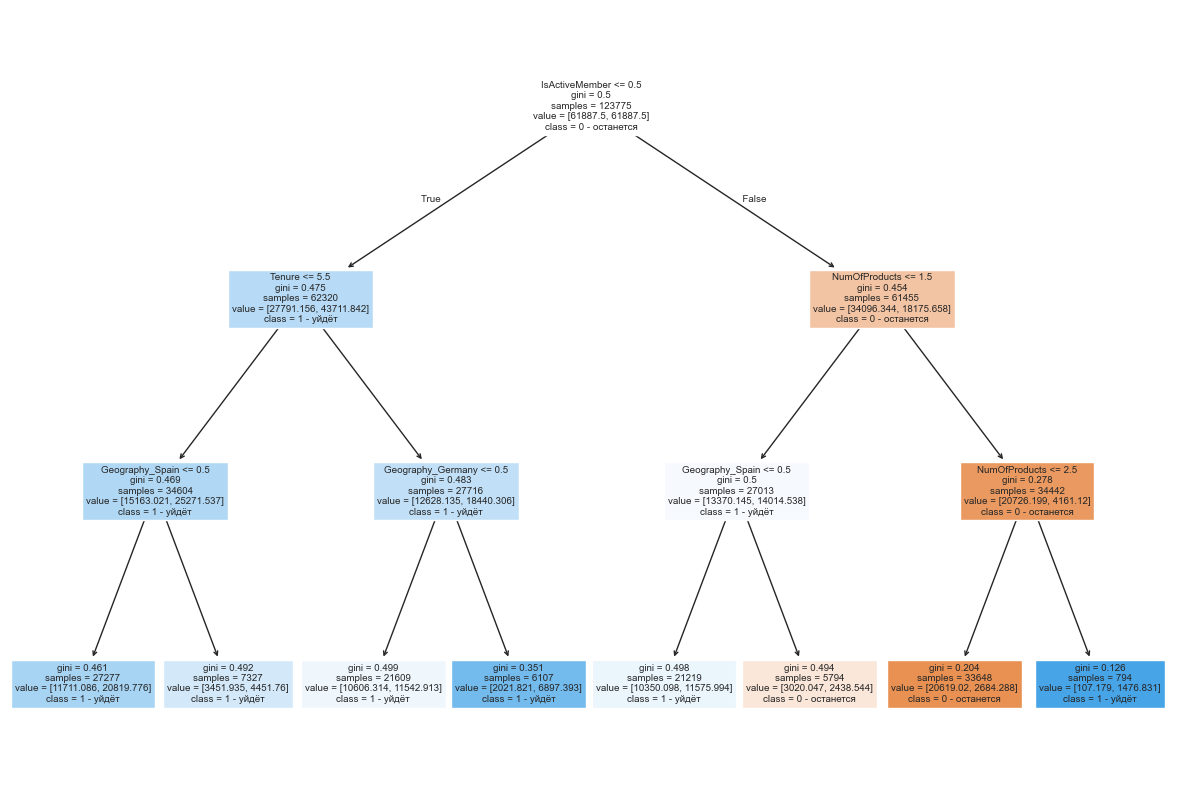

In [88]:
tree_optuna = pipeline_dt.named_steps['clf']
feature_names = pipeline_dt.named_steps['preprocessor'].get_feature_names_out()
plt.figure(figsize=(15, 10))
plot_tree(
    tree_optuna,
    feature_names=feature_names,
    class_names=["0 - останется", "1 - уйдёт"],
    filled=True,  # расцветка графа
)
plt.show()

#### 2.4 Feature Importance

             Feature  Importance
7      NumOfProducts    0.495301
9     IsActiveMember    0.409469
1  Geography_Germany    0.078902
2    Geography_Spain    0.012935
5             Tenure    0.003393


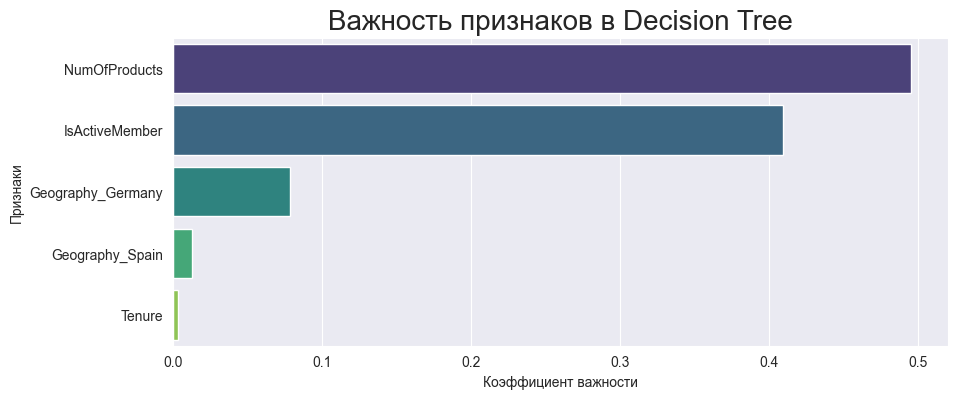

In [89]:
importances = tree_optuna.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(5)

print(feat_imp_df)

plt.figure(figsize=(10, 4))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Важность признаков в Decision Tree', fontsize=20)
plt.xlabel('Коэффициент важности')
plt.ylabel('Признаки')
plt.show()

Важные признаки в этом конкретном дереве: число продуктов, активен ли клиент и локация. Позднее сравним с ансамблем деревьев

### 3. Случайный лес

#### 3.1 RandomForestClassifier + Optuna

In [90]:
def objective_ensemble(trial):
    n_estimators = trial.suggest_int('n_estimators', 25, 150, step=25)
    max_depth = trial.suggest_int('max_depth', 2, 10)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 6)  # по Брейману 1-3 для классификации
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    class_weight = trial.suggest_categorical('class_weight', ['balanced'])

    model = RandomForestClassifier(n_estimators=n_estimators,
                                   random_state=RANDOM_STATE,
                                   max_depth=max_depth,
                                   min_samples_leaf=min_samples_leaf,
                                   min_samples_split=min_samples_split,
                                   max_features=max_features,
                                   class_weight=class_weight,
                                   )
    pipeline = Pipeline([
        ('preprocessor', tree_preproc),
        ('clf', model)
    ])
    recall = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring="recall", n_jobs=1).mean()
    return recall

In [91]:
# Фиксируем сэмплер Optuna
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

study_rf = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="RandomForest"
)
start = time.perf_counter()
study_rf.optimize(objective_ensemble, n_trials=40, timeout=500, show_progress_bar=True)
total_duration_rf = time.perf_counter() - start

[I 2026-04-27 14:38:10,079] A new study created in memory with name: RandomForest


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-04-27 14:38:22,467] Trial 0 finished with value: 0.773281174028609 and parameters: {'n_estimators': 75, 'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.773281174028609.
[I 2026-04-27 14:38:26,339] Trial 1 finished with value: 0.7824445863419422 and parameters: {'n_estimators': 25, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.7824445863419422.
[I 2026-04-27 14:38:34,174] Trial 2 finished with value: 0.7741972744141581 and parameters: {'n_estimators': 125, 'max_depth': 3, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.7824445863419422.
[I 2026-04-27 14:38:40,108] Trial 3 finished with value: 0.8027185645749885 and parameters: {'n_estimators': 75, 'max_depth': 4, 'min_samples_split': 7, 'min_samples_lea

In [92]:
rf_params = study_rf.best_params
rf_score = study_rf.best_value

print(f"\nОбщее время работы Optuna: {total_duration_rf:.2f} сек")
print(f'Лучшие параметры: {rf_params}')
print(f"CV-метрика Recall на train (среднее): {rf_score:.4f}")


Общее время работы Optuna: 182.59 сек
Лучшие параметры: {'n_estimators': 25, 'max_depth': 2, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': 'balanced'}
CV-метрика Recall на train (среднее): 0.8337


Возьмем лучшие гиперпараметры и порог 0.4

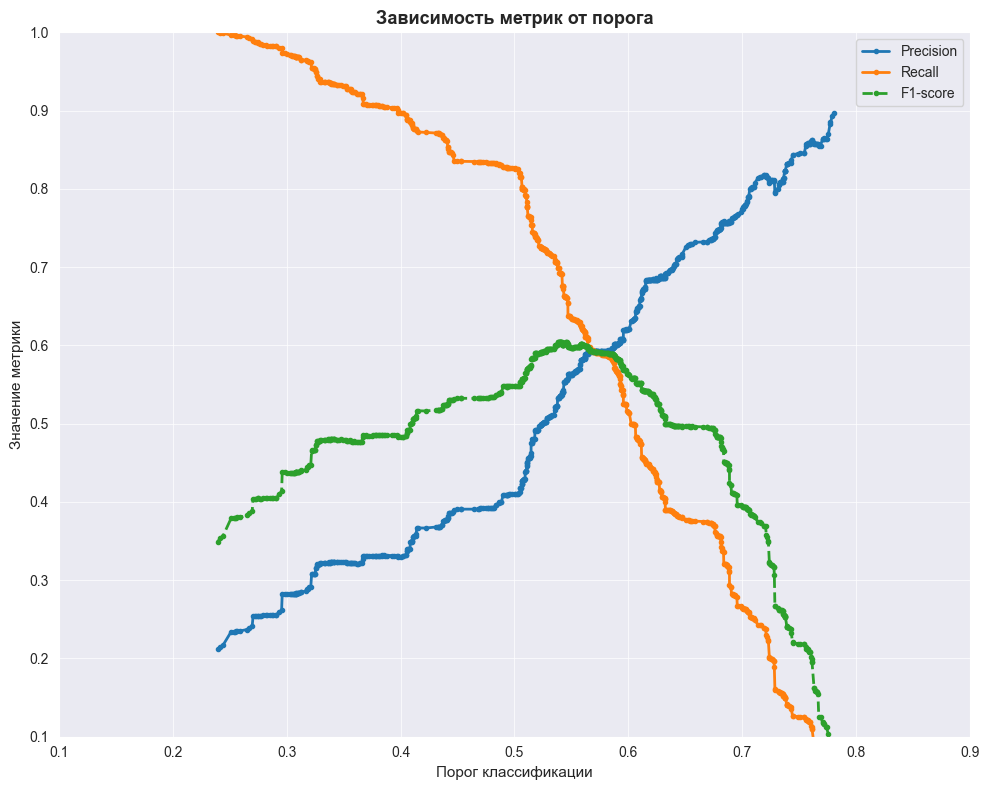


CV-метрики на train (RandomForest + Optuna):
  average_precision: 0.63 ± 0.00
  recall      : 0.83 ± 0.00

Classification Report на test:
              precision    recall  f1-score   support

           0       0.95      0.51      0.66     32529
           1       0.33      0.90      0.48      8730

    accuracy                           0.59     41259
   macro avg       0.64      0.70      0.57     41259
weighted avg       0.82      0.59      0.63     41259

PR-AUC (test): 0.6215


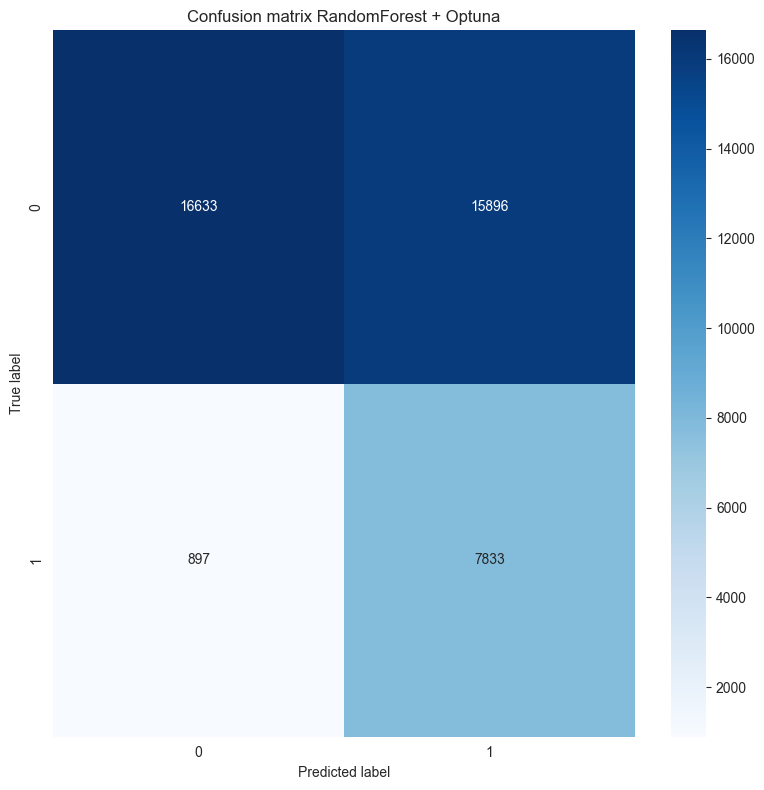

In [93]:
pipeline_rfc = Pipeline([
    ('preprocessor', tree_preproc),
    ('clf', RandomForestClassifier(**study_rf.best_params, random_state=RANDOM_STATE))
])

start_rf = time.perf_counter()
pipeline_rfc.fit(X_train, y_train)
time_rf = round(time.perf_counter() - start_rf, 2)

proba_rf = pipeline_rfc.predict_proba(X_test)[:, 1]
plot_metrics_vs_threshold(y_test, proba_rf)
pred_rf = (proba_rf >= threshold)
cv_metrics_rf = cross_validate(
    pipeline_rfc, X_train, y_train, cv=skf,
    scoring=['average_precision', 'recall'],
    return_train_score=False, n_jobs=-1
)
print_metrics(y_test, pred_rf, proba_rf, cv_metrics_rf, "RandomForest + Optuna")

#### Вывод:

По подбору гиперпараметров Optuna достигнут потолок в скорах. Дальнейшее увеличение диапазонов параметров и итераций подбора не дают результата. 

Видим, что ансамбль решающих деревьев дает меньший Recall=0.90 по сравнению с одним деревом (0.95). Решающее дерево чувствительно к подбору 
гиперпараметров. Нам удалось подобрать оптимальные. Что дало низкий Bias. Но у ансамблей в целом меньше стандартное отклонение в sqrt(N) раз => стабильнее результат

PR-AUC значительно вырос  0.36 -> 0.62. Ранжирующая способность ансамбля выше

Переходим к градиентному бустингу на решающих деревьях. Но сначала проанализируем важность признаков на ансамбле деревьев 

#### 3.2 Feature Importance

             Feature  Importance
4                Age    0.419483
7      NumOfProducts    0.346539
9     IsActiveMember    0.095990
1  Geography_Germany    0.083843
0        Gender_Male    0.033538
6            Balance    0.016694
2    Geography_Spain    0.003046
3        CreditScore    0.000866


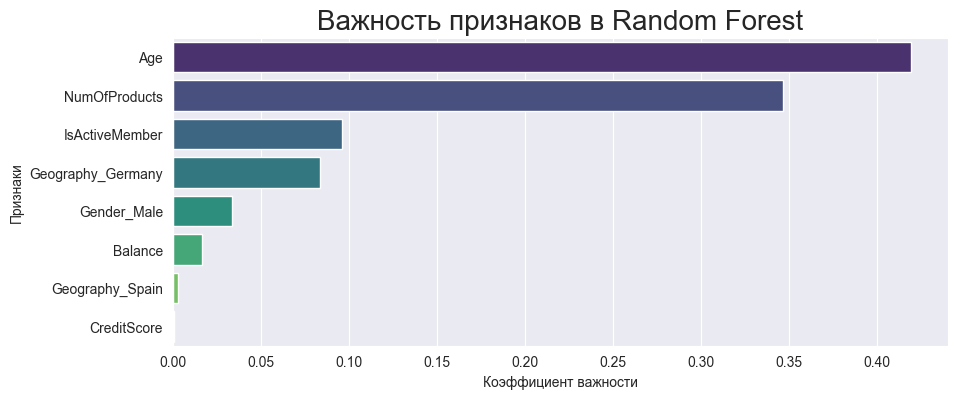

In [94]:
final_model = pipeline_rfc.named_steps['clf']
preprocessor_step = pipeline_rfc.named_steps['preprocessor']
feature_names = preprocessor_step.get_feature_names_out()
importances = final_model.feature_importances_

# Собираем в DataFrame для удобства
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(8)

print(feat_imp_df)

# Визуализация
plt.figure(figsize=(10, 4))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Важность признаков в Random Forest', fontsize=20)
plt.xlabel('Коэффициент важности')
plt.ylabel('Признаки')
plt.show()

#### Вывод:
В ансамбле деревьев, по сранению с одним решающим деревом, другие признаки оказались важнее для классификации: 

проявился признак `Age` - самый важный 

`NumOfProduct` (следующий по важности), `isActiveMember` и `Geography` по-прежнему важны

проявились признаки `Balance` и `Gender` 

### 4. CatBoost

#### 4.1 Базовая модель

Установим стандартные параметры: learning rate 0.01, глубина 6, побольше итераций 2000 - 2500. В качестве метрики для ранней остановки выставим PR-AUC. Recall здесь не подойдет, т.к. разработчики CatBoost не рекомендует дискретные метрики для критерия останова ( eval_metric должен быть гладкой вероятностной метрикой ). 

Добавим в  категориальные признаки все дискретные (не float). Эксперименты (не приведены в ноутбуке) показали эту стратегию выигышной.

In [95]:
cat_features = ['Geography', 'Gender',
                'Tenure',
                'NumOfProducts', 'HasCrCard', 'IsActiveMember'
                ]
print(X.nunique())

CreditScore          457
Geography              3
Gender                 2
Age                   69
Tenure                11
Balance            30075
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary    55298
dtype: int64


In [96]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)
train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

cb_model = CatBoostClassifier(
    iterations=2500,
    learning_rate=0.01,
    depth=6,
    loss_function='Logloss',
    eval_metric='PRAUC',  # метрика для early stopping и графика
    custom_metric=['Recall', 'PRAUC'],
    auto_class_weights='Balanced',
    random_seed=RANDOM_STATE,
    verbose=100,
)
start_base = time.perf_counter()
cb_model.fit(
    train_pool,
    eval_set=val_pool,
    early_stopping_rounds=50
)
time_base = round(time.perf_counter() - start_base, 2)

0:	learn: 0.8694361	test: 0.8651231	best: 0.8651231 (0)	total: 31.4ms	remaining: 1m 18s
100:	learn: 0.8866774	test: 0.8836938	best: 0.8836938 (100)	total: 2.53s	remaining: 1m
200:	learn: 0.8885469	test: 0.8851566	best: 0.8851566 (200)	total: 5.44s	remaining: 1m 2s
300:	learn: 0.8898393	test: 0.8860590	best: 0.8860590 (300)	total: 8.69s	remaining: 1m 3s
400:	learn: 0.8907336	test: 0.8866605	best: 0.8866605 (400)	total: 13.2s	remaining: 1m 8s
500:	learn: 0.8913741	test: 0.8870126	best: 0.8870128 (499)	total: 16.7s	remaining: 1m 6s
600:	learn: 0.8918986	test: 0.8872823	best: 0.8872833 (599)	total: 19.9s	remaining: 1m 3s
700:	learn: 0.8923287	test: 0.8874545	best: 0.8874572 (697)	total: 23.2s	remaining: 59.4s
800:	learn: 0.8927231	test: 0.8876088	best: 0.8876121 (796)	total: 26.4s	remaining: 55.9s
900:	learn: 0.8930637	test: 0.8877024	best: 0.8877024 (900)	total: 29.5s	remaining: 52.4s
1000:	learn: 0.8933745	test: 0.8877857	best: 0.8877877 (997)	total: 32.7s	remaining: 49s
1100:	learn: 0.8

Время работы базового классификатора CatBoost: 57.59 сек
Обучение заняло: 57.59 сек
Лучшая итерация: 1634
Best Recall: 0.8003
Best PR-AUC: 0.8883


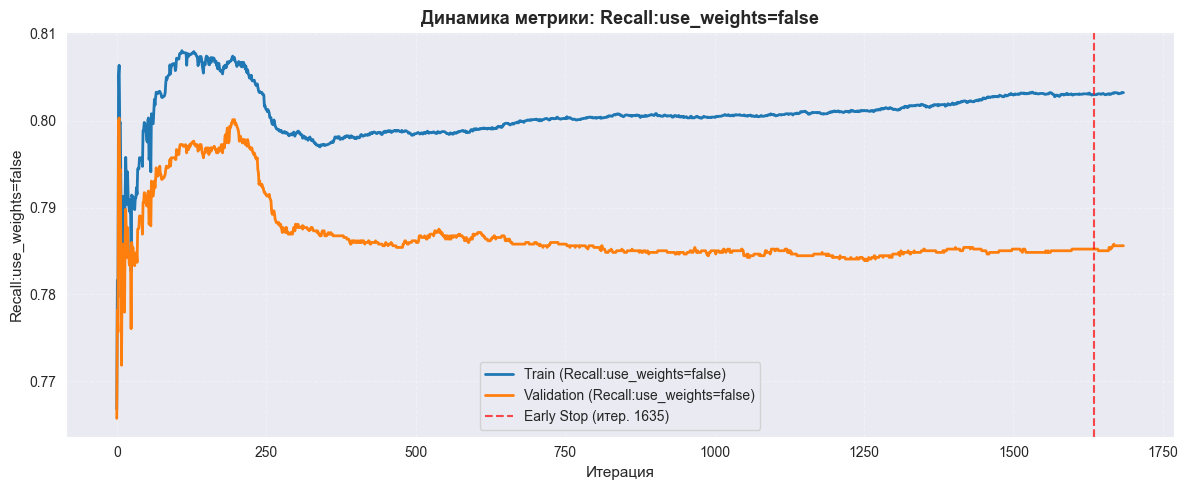

In [97]:
print(f"Время работы базового классификатора CatBoost: {time_base} сек")
recall_key = 'Recall:use_weights=false'
best_score = cb_model.get_best_score()
best_iter = cb_model.get_best_iteration()

best_recall = best_score['validation'][recall_key]
best_prauc = best_score['validation']['PRAUC']

print(f"Обучение заняло: {time_base} сек")
print(f"Лучшая итерация: {best_iter}")
print(f"Best Recall: {best_recall:.4f}")
print(f"Best PR-AUC: {best_prauc:.4f}")
plot_catboost_metrics(cb_model, metric_name=recall_key)

#### 4.2 Подбор гиперпараметров Optuna

In [98]:
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.15, log=True),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.001, 10.0, log=True),
        'rsm': trial.suggest_float('rsm', 0.8, 1.0),  # семплинг фичей  
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),  # семплинг объектов
        'custom_metric': ['Recall', 'PRAUC'],
        'auto_class_weights': 'Balanced',
        'eval_metric': 'PRAUC',
        'random_seed': RANDOM_STATE,
        'verbose': 0,
        'thread_count': 1,
        'iterations': 2500,
        'early_stopping_rounds': 50,
    }
    model = CatBoostClassifier(**params)

    pruning_cb = optuna.integration.catboost.CatBoostPruningCallback(trial, metric='PRAUC')

    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=50,
        callbacks=[pruning_cb],
        verbose=0
    )
    return recall_score(y_val, model.predict(X_val))


study_cb = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="CatBoost + Optuna"
)
start_opt = time.perf_counter()
study_cb.optimize(objective, n_trials=40, show_progress_bar=True, n_jobs=-1)
total_duration_opt = time.perf_counter() - start_opt

[I 2026-04-27 14:42:12,046] A new study created in memory with name: CatBoost + Optuna


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-04-27 14:42:35,468] Trial 7 finished with value: 0.7819778541428026 and parameters: {'learning_rate': 0.07768838021695439, 'depth': 10, 'l2_leaf_reg': 0.05442507329647151, 'rsm': 0.8903150613033537, 'subsample': 0.6518264216570607}. Best is trial 7 with value: 0.7819778541428026.
[I 2026-04-27 14:43:06,299] Trial 9 finished with value: 0.7827415043909889 and parameters: {'learning_rate': 0.051338766185810576, 'depth': 8, 'l2_leaf_reg': 0.6240298325745772, 'rsm': 0.9762522322190812, 'subsample': 0.5170006146745042}. Best is trial 9 with value: 0.7827415043909889.
[I 2026-04-27 14:43:20,562] Trial 1 finished with value: 0.7856051928216876 and parameters: {'learning_rate': 0.0685170327955752, 'depth': 5, 'l2_leaf_reg': 0.046008183349290396, 'rsm': 0.9501716635889803, 'subsample': 0.7491784479048048}. Best is trial 1 with value: 0.7856051928216876.
[I 2026-04-27 14:43:33,279] Trial 10 finished with value: 0.7857961053837342 and parameters: {'learning_rate': 0.052502168954260645, 'd

In [99]:
cb_params = study_cb.best_params.copy()
cb_score = study_cb.best_value

print(f"\nОбщее время работы Optuna: {total_duration_opt:.2f} сек")
print(f'Лучшие параметры: {cb_params}')
print(f"CV-метрика Recall на train (среднее): {cb_score:.4f}")


Общее время работы Optuna: 204.25 сек
Лучшие параметры: {'learning_rate': 0.022352693470433446, 'depth': 4, 'l2_leaf_reg': 0.6454229699215256, 'rsm': 0.9029722768052816, 'subsample': 0.5699361387806343}
CV-метрика Recall на train (среднее): 0.8318


##### Вывод:
Prunning колл-бэк значительно ускоряет подбор - 3-4 минуты

#### 4.3 Модель с подобранными гиперпараметрами

In [100]:
cb_params.update({
    'custom_metric': ['Recall', 'PRAUC'],
    'auto_class_weights': 'Balanced',
    'eval_metric': 'PRAUC',
    'random_seed': RANDOM_STATE,
    'verbose': 0,
    'thread_count': 1,
    'iterations': 2000,
    'early_stopping_rounds': 50,
})
cb_opt = CatBoostClassifier(**cb_params)

start_cb = time.perf_counter()
cb_opt.fit(train_pool,
           eval_set=val_pool)
time_cb = round(time.perf_counter() - start_cb, 2)

Время работы CatBoost: 110.02 сек
Обучение заняло: 110.02 сек
Лучшая итерация: 1695
Best Recall: 0.83181
Best PR-AUC: 0.88837


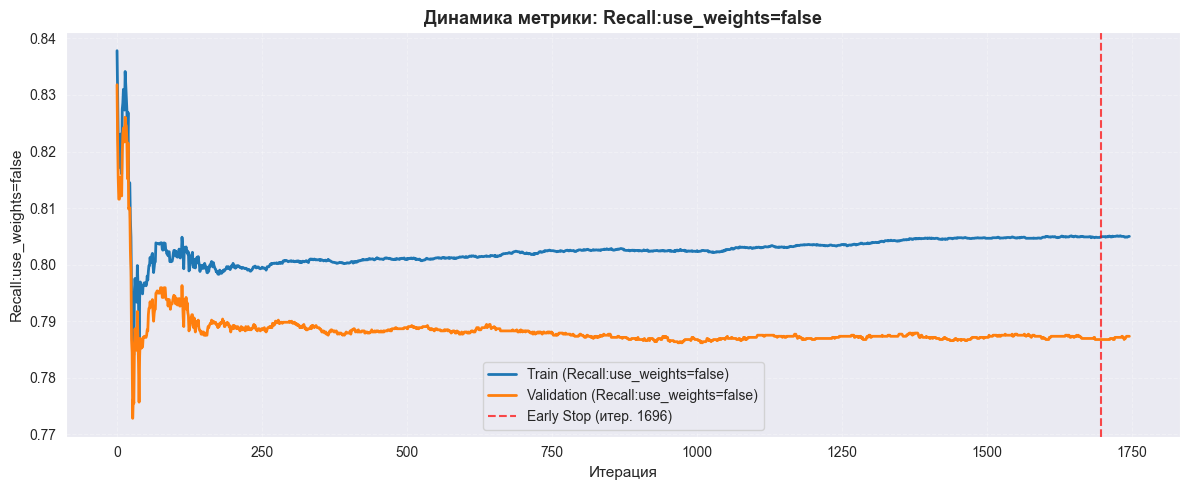

In [101]:
print(f"Время работы CatBoost: {time_cb} сек")
best_scores = cb_opt.get_best_score()
best_iter_opt = cb_opt.get_best_iteration()

best_recall_opt = best_scores['validation'][recall_key]
best_prauc_opt = best_scores['validation']['PRAUC']

print(f"Обучение заняло: {time_cb} сек")
print(f"Лучшая итерация: {best_iter_opt}")
print(f"Best Recall: {best_recall_opt:.5f}")
print(f"Best PR-AUC: {best_prauc_opt:.5f}")
plot_catboost_metrics(cb_opt, metric_name=recall_key)

#### 4.4 Подбор порога

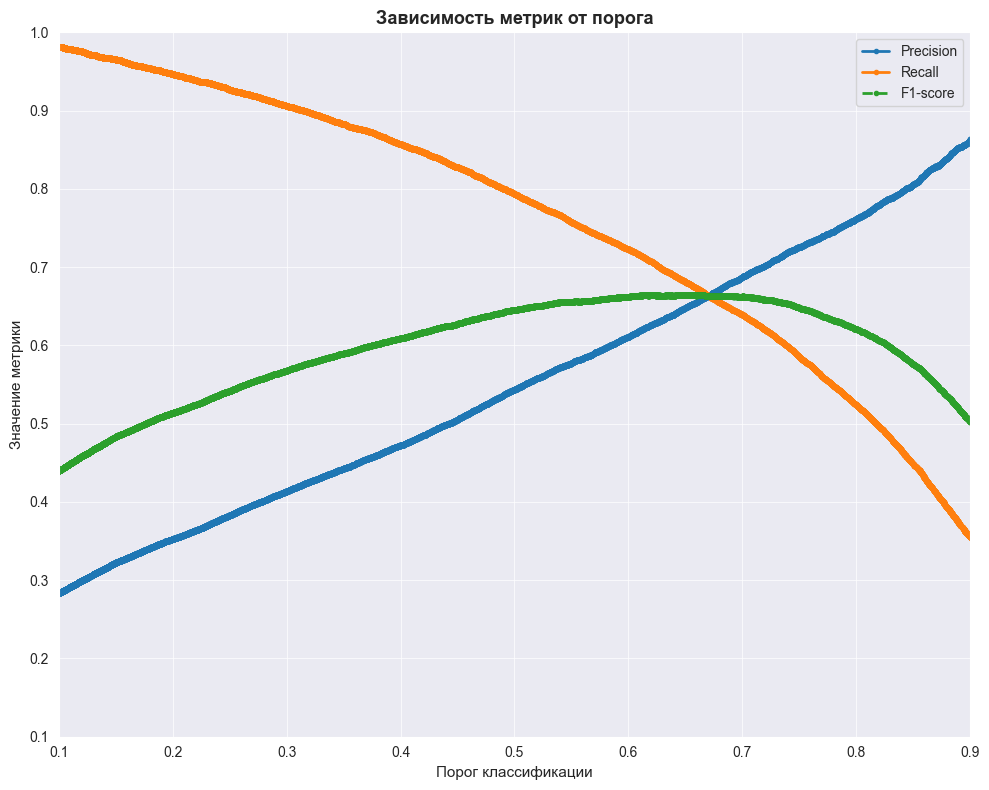

In [102]:
proba_cp_opt = cb_opt.predict_proba(X_test)[:, 1]
plot_metrics_vs_threshold(y_test, proba_cp_opt)

Видим, что при другом пороге (0.25) можем сохранить приемлемую точность > 0.35 и получить максимальную полноту




Classification Report на test:
              precision    recall  f1-score   support

           0       0.97      0.60      0.74     32529
           1       0.38      0.93      0.54      8730

    accuracy                           0.67     41259
   macro avg       0.68      0.76      0.64     41259
weighted avg       0.84      0.67      0.70     41259

PR-AUC (test): 0.7286


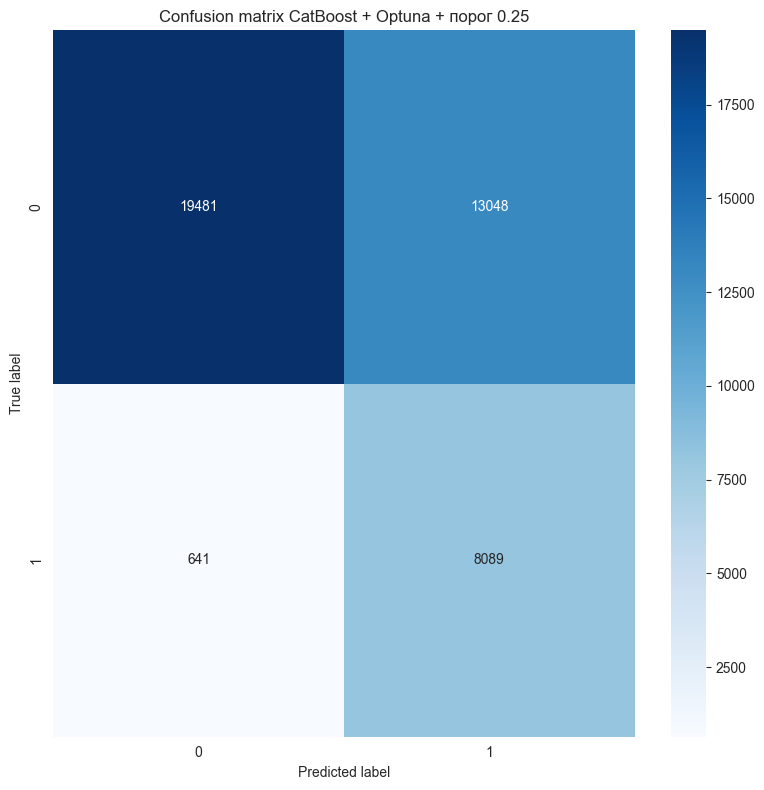

In [103]:
cb_threshold = 0.25
pred_opt = (proba_cp_opt >= cb_threshold)
print_metrics(y_test, pred_opt, proba_cp_opt, pipeline_name="CatBoost + Optuna + порог 0.25")

#### 4.5 Важность признаков

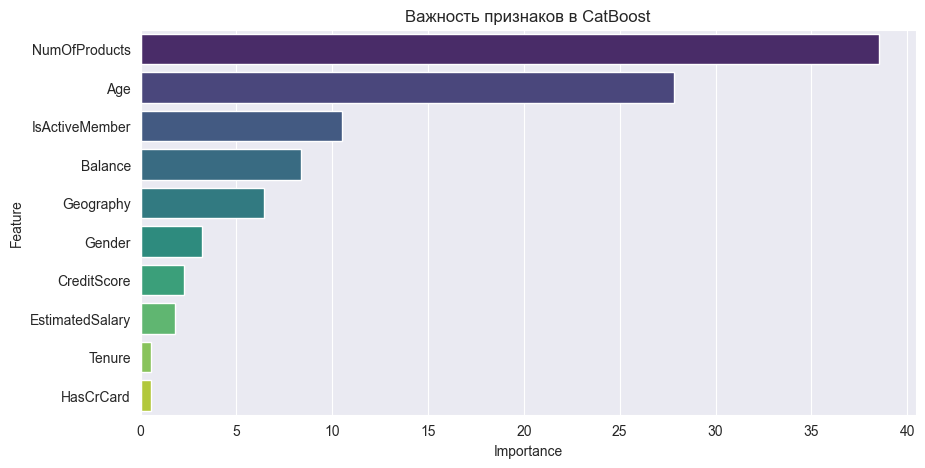

In [104]:
feature_names_model = cb_opt.feature_names_
feature_importance = cb_opt.get_feature_importance(train_pool)
fi_df = pd.DataFrame({
    'Feature': feature_names_model,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)
plt.title('Важность признаков в CatBoost')
plt.show()

### 5. Итоговая таблица

In [105]:
data = {
    "Модель": ["LogisticRegression", "DecisionTreeClassifier", "RandomForest", "CatBoostClassifier"],
    "Recall": [0.84, 0.95, 0.90, 0.93],
    "PR_AUC": [0.57, 0.36, 0.62, 0.72],
    "Порог": [threshold, threshold_dt, threshold, cb_threshold],
    "FalseNegative": [1410, 411, 897, 568],
    "Время_обучения": [time_lr, time_dt, time_rf, time_cb]
}
df = pd.DataFrame(data).set_index("Модель")

print("\nСравнение моделей (по метрикам):")
print(df.T.to_string(max_rows=10, line_width=200))


Сравнение моделей (по метрикам):
Модель          LogisticRegression  DecisionTreeClassifier  RandomForest  CatBoostClassifier
Recall                        0.84                    0.95          0.90                0.93
PR_AUC                        0.57                    0.36          0.62                0.72
Порог                         0.40                    0.45          0.40                0.25
FalseNegative              1410.00                  411.00        897.00              568.00
Время_обучения                0.16                    0.07          0.39              110.02


### Выбор модели: 

2 фаворита по метрике Recall:

* DecisionTree: максимальный Recall=0.95 с порогом и минимальная ошибка первого рода FN=411. Но ранжирующая способность модель низкая PR-AUC=0.36. На новых данных риск ложных срабатываний. Модель выигрывает во времени обучения.
* CatBoost: почти такой же высокий Recall=0.93 с порогом . Максимальный PR-AUC=0.72, значит модель увереннее различает классы. Будет меньше ложных срабатываний при том же уровне детекции. 
К тому же бустинг + регуляризация снижают риск переобучения, в отличие от одного дерева. Плюс встроенная обработка категориальных признаков, поддержка Pool для быстрого инференса.

Наш выбор - CatBoost. Она не пропускает целевое событие (отток клиентов) и стабильна на новых данных 

In [106]:
_ = cb_opt.predict(test_pool) # прогрев

start_inf = time.perf_counter()
for _ in range(5):
    _ = cb_opt.predict(test_pool)
total = time.perf_counter() - start_inf
print(f"Инференс: {(total/5/len(X_test))*1000:.4f} мс/объект")

Инференс: 0.0005 мс/объект
